# 4차시 딥러닝 2.Focus on Transformer
#### 조대흠

---


## 1. 인트로


### 1-1 RNN의 한계와 어텐션의 등장

#### Attention의 등장

- Seq2Seq: input 내용을 다른 시퀀스로 변환하는 모델 구조

    - 장점: 입력과 출력의 단어 개수가 같지 않아도 사용 가능 / 다양한 변화 작업에 적용 가능

    - Encoder: 입력 데이터를 순서대로 읽고 context vector로 표현 / Decoder: contextvector기반 출력시퀀스 생성

- Seq2Seq -> 모든 정보를 하나의 고정된 Context Vector에 압축 -> 입력 문자이 길어질수록 하나의 벡터에 모든 정보 담기 힘듬 -> Attention의 등장

- Attention: 중요한 정보에 더 집중하는 메커니즘. 현재 시점에서 가장 중요한 부분에 더 높은 가중치를 부여하여 활용
    - 출력 시점마다 새로운 context vector을 동적으로 계산 -> 병렬화

### Attention 메커니즘의 장저

- 시간 경과에 대한 유연성(vs RNN)
    - RNN은 장기 의존성 문제를 가진다.
    - Attention은 모든 단어에서 다른 모든 단어로 직접 연결될 수 있다.

- 공간에 대한 유연성(vs CNN)
    - CNN은 고정된 필터를 사용해 이미지의 지역적 부분 중심으로 정보 처리
    - Attention은 이미지의 모든 픽셀이 다른 모든 픽셀로 직접 연결 -> 한번에 전체 이미지의 전역적 관계 학습가능

- 병렬화 (vs RNN)
    - RNN은 순차 계산이 필수적이기 때문에 병렬 처리가 어렵고, 학습 속도가 매우 느림
    - Attention은 self-attention에서 문장 내 모든 단어의 관계를 한번에, 독립적으로 계산 가능



### 1-2 Attention is All You Need

- 논문 배경: RNN과 RNN 기반 모델들의 한계점 -> 순차적 계산 구조를 제거하는것

- Transformer: self-attention에 기반한 Transformer 모델 제안

- 논문에서 가장 중요한 발견: Recurrence 및 Convolution이 필수가 아님 / 병렬화 가능

- 파급효과: LLM의 탄생, NLP평정, CV등으로의 확장

#### Transformer

- Transformer은 RNN의 순차적 계산 구조를 버리고, Attention만으로 문장의 의미와 구조를 파악하는 모델

- Transformer의 핵심 기술
    1. Self-Attention: 문장 안에서 어떤 단어가 다른 단어들과 얼마나 중요한 관계를 맺고 있는지 한번에 파악

    2. Multi-Head Attention: 셀프 어텐션을 여러개의 head로 동시에 서로 다른 관점에서 실행

    3. Positional Encoding: 단어의 위치정보를 벡터에 추가

---
## 2. Self-Attention

### 2-1. Query, Key, Value

| Q, K, V 개념

- Q: Query
    - 쿼리는 질문 또는 요청으로, 지금 당장 내가 알고 싶거나 초점을 맞추고 있는 대상

- K: Key
    - 검색 대상이 되는 모든 정보들이 달고 있는 이름표 또는 색인

- V: Value
    - 키와 한쌍으로 묶여 있는 '실제 내용물' - 쿼리, 키 관련도 계산이 끝나고, 가장 관련성이 높은 키가 선택시, 그 해당 밸류를 가져옴


### 2-2. 기존 Cross-Attention vs Self-Attention

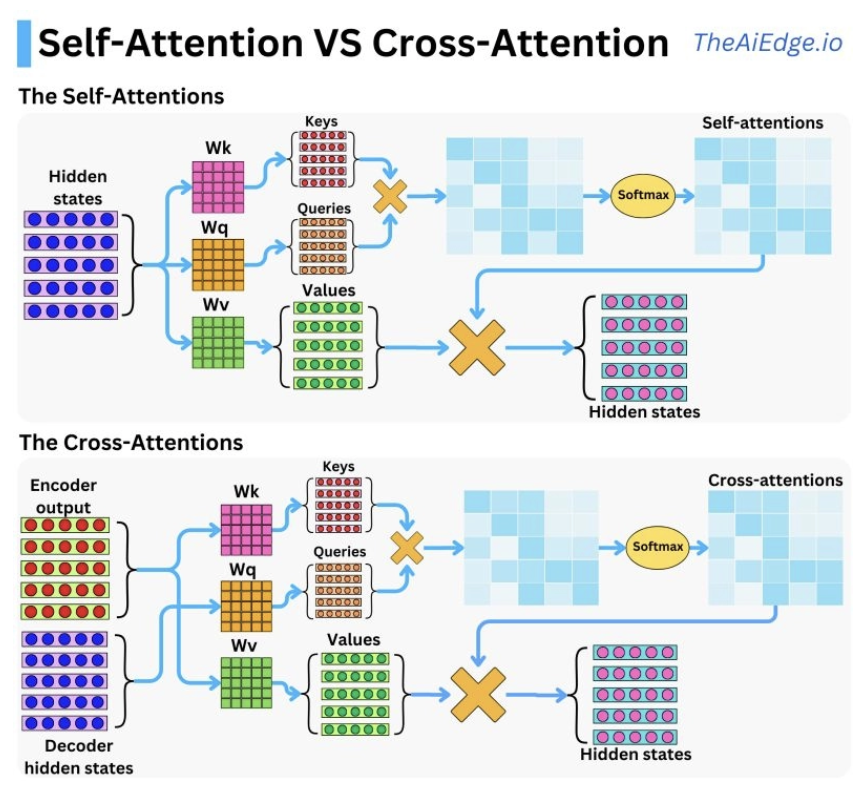

| 구분 | 기존 어텐션 (Cross-Attention) | 셀프 어텐션 (Self-Attention) |
| --- | --- | --- |
| 핵심 아이디어 | 번역할 문장을 보면서 단어를 생성 | 문장 자체를 뜯어보며 내부 관계를 파악 |
| 작동 방식 | 하나의 시퀀스가 완전히 다른 시퀀스를 참고하여 정보를 만들어내는 메커니즘 | 한 문장 내 모든 단어끼리 서로의 관계를 계산 |
| 참조 대상 | 서로 다른 시퀀스 (인코더 ↔ 디코더) | 동일한 시퀀스 (문장 내부 ↔ 문장 내부) |
| 주요 목적 | 인코더-디코더 연결, 정보 병목 현상 해소 | 시퀀스 내부의 문맥 및 의존 관계 파악 |
| 기반 아키텍처 | RNN (LSTM, GRU) | 트랜스포머 (Attention Only) |
| 병렬 처리 | 불가능  | 가능  |

#### 기존 Attention in Seq2Seq(Cross - Attention)

- Query와 Key - Value 쌍이 서로 다른 시퀀스에서 출력

- Cross - Attention은 Decoder가 Encoder을 참고해 정보를 만들어냄

#### Self - Attention

- 각 단어를 벡터로 임베딩 -> 단어 간 유사도 계산 -> softmax & attention 가중치로 중요도 배분 -> 새로운 벡터 생성


### 2-3. Scaled Dot-Product Attention

#### Dot-Product Attention

- Dot-Product Attention은 Query Key를 내적하여 유사도를 구한 것
- but Attention Score의 극단화 발생 -> 벡터의 차원이 커질 수록, 내적값이 극단값으로 가며, Softmax통과시 gradient가 0에 가까워짐

#### Scaled Dot-Product Attention

- Q - K 내적을 한 후, 값의 크기를 맞추는 스케일링 과정을 추가
    - Q-K 내적 후, root(d_k)로 나누어 스케일링 진행 -> Softmax -> Attention Weight 산출 -> V벡터에 곱하여 최종 결과값 산출

---

## 3. Multi-Head Attention

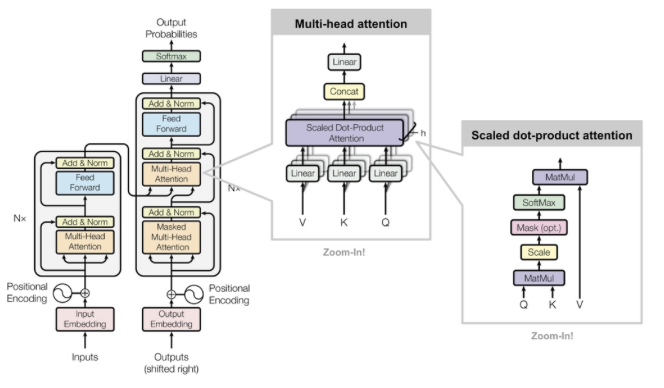

Encoder에서 한번, Decoder에서 두번 사용(Decoder에서는 Masked Multi head Attention, Encoder-Decoder Attention)

### 3-1 Why Multi-Head Attention?

- Single-Head Attention -> 하나의 어텐션 분포 안에서 각 단어 간 문법적 관계, 의미적, 위치 관계 등 모든 정보가 한 번에 담겨 가중평균을 구함
    - -> 이로 인해 각 단어의 중요한 관계를 놓칠 수 있음

- Multi-Head Attention -> 한 단어와 다른 단어간의 관계를 여러 차원으로 나누어 병렬로 학습
    - 512차원의 입력 벡터를 64차원씩 8개의 벡터로 나누고, Attention 스코어를 병렬로 여러번 계산


### 3-2 Multi-Head Attention 작동 방식

- 분할: 512차원 벡터로 표현된 단어 하나를, 8개의 작은 벡터 그룹 (Q,K,V)로 투영해 8개의 서로 다른 관점으로 나눔

- 병렬 어텐션 계산: 8개의 헤드들이 서로 간섭하지 않고, 병렬로 Scaled Dot-Product Attention 계산
    - Attention 점수 계산 -> scaling -> softmax -> weighted sum: 64차원의 결과 벡터 나옴

- 결합 및 최종 투영: 8개의 head에서 나온 것들을 concat -> projection

---

## 4. Transformer 전체 아키텍처

### 4-1. 트랜스포머의 전처리 단계

트랜스포머: 텍스트 입력 -> 토큰 임베딩 -> Positional Encodng

- 토큰화: 입력 텍스트를 모델이 처리할 수 있는 token으로 나눔    
    - 보통 하나의 토큰 = 하나의 단어 / 문장부호도 하나의 토큰 / but 일부 단어는 하나 이상의 토큰으로 나뉠 수 있음

- 임베딩: 토큰화된 각 토큰은 임베딩 단계에서 숫자의 벡터로 변환됨
    - 임베딩은 많은 숫자로 이루어진 긴 벡터로 단어를 나타냄 -> 벡터 길이 -> 벡터 차원
    - 단어의 의미를 공간적으로 표현하는 것 인데, 유사한 단어는 유사한 공간에 임베딩 된다.
    - Word2Vec

- Positional Encoding: 단어들의 순서 정보를 임베딩 벡터에 추가
    - Transformer은 모든 단어를 병렬로 처리하기 때문에, 단어의 순서를 알지 못함


### 4-2. 트랜스포머의 Encoder와 Decoder

#### Encoder

Encoder은 입력 문장을 이해하고 오약된 의미 벡터로 변환 - 전처리 과정 및 인코더 레이어로 구성

- 인코더 레이어의 구성: Multi-Head Attention + Feed-Forward

- Feed-Forward Layer: 입력 벡터의 차원을 확정하고 비선형 변환을 적용해 새로운 표현을 생성하는 신경망 구조
    - MLP가 2층으로 연결된 구조로, 단어에 대해 심층 분석을 진행하는 것

- Add & Norm: 입력값을 그대로 출력에 더해주는 것

- Layer Normalization: 입력 벡터의 평균과 분산을 사용해서 정규화 하는 것


#### Decoder

Decoder은 Encoder가 분석한 입력 문장의 의미 벡터를 받아 출력 문장을 순차적으로 생성하는 역할

전처리 과정, 디코더 레이어, 선형 레이어, 소프트맥스 레이어로 이루어져있음

- Decoder Layer의 구성: Masked Multi-Head Attention + Encoder-Decoder Multi Head Attention + Feed-Forward Layer

- Masked Multi-Head Attention: 미래 시점의 단어 정보를 참고하지 못하도록 마스킹을 적용한 Attention 알고리즘

- Encoder - Decoder Attention(Cross - Attention): 디코더가 인코더의 Context를 참고하면서 현재 생성중인 단어를 입력 문장의 의미와 연결
    - Q: 디코더의 이전 서브레이어 출력, K,V: 인코더의 최종 출력(Context Vector)



### 4-3 전체 모델 및 데이터 흐름

입력 준비(문장 의미 + 위치 vec 변환) -> Encoder에서 문맥적의미 파악(Self-Attention -> Q-K dot -> Softmax -> 가중합 -> Multi-head Attention): Context Vector = Decoder의 K,V -> Decoder에서 번역 문장 한단어씩 생성: Masked Self-Attention -> Encoder-Decoder Attention: 최종 문장 생성

---